<a href="https://colab.research.google.com/github/duyendh/ELM/blob/main/ELM_Energy_Minimization_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running on: cpu
Starting MNIST experiment...
Starting FashionMNIST experiment...

Experimental Results:
| Dataset      |   ELM Acc |   ELM Time |   BP Acc |   BP Time |
|:-------------|----------:|-----------:|---------:|----------:|
| MNIST        |     85.13 |       0.24 |    92.99 |     14.71 |
| FashionMNIST |     77.57 |       0.22 |    68.55 |     14.12 |

Generating plot...
Plot saved as elm_vs_bp_results.png


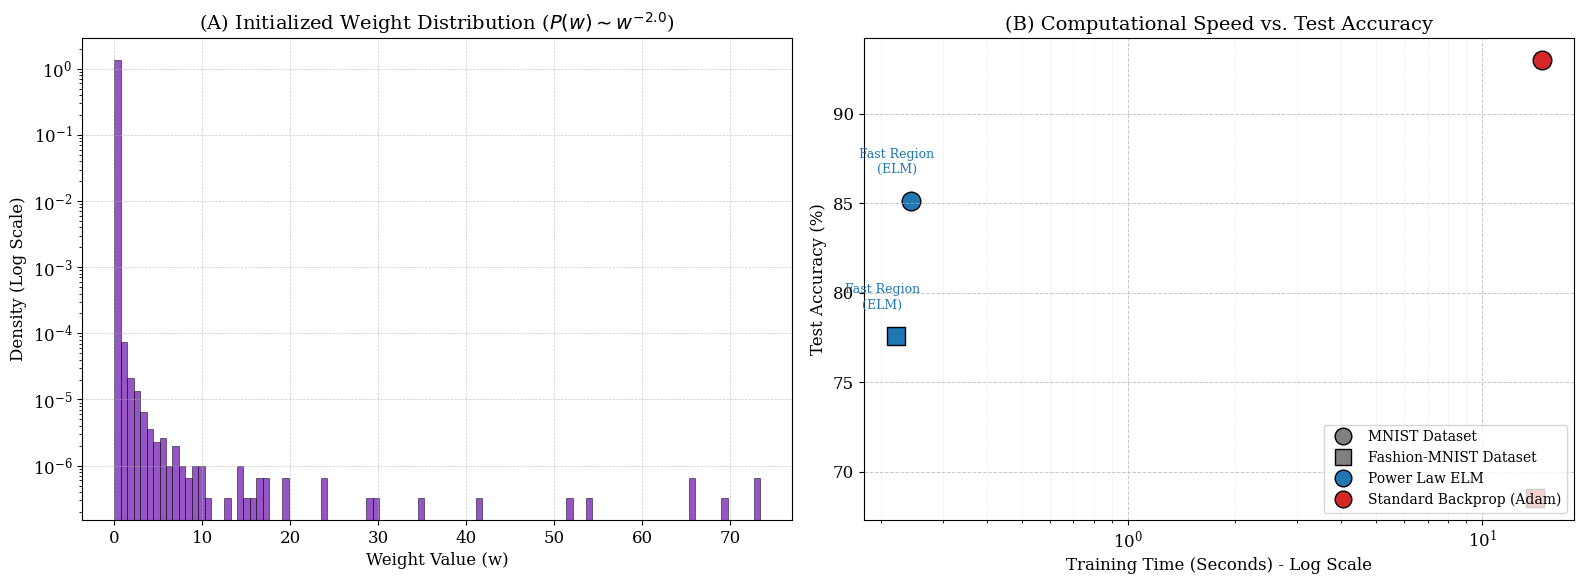

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Set seeds for reproducibility in the paper
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

# --- 1. Define Initialization and Experiment Functions ---
def power_law_init(shape, alpha=2.0):
    """Generates weights following P(w) ~ w^(-alpha) via inverse transform sampling."""
    u = torch.rand(shape)
    # Avoid exactly 0 or 1 for numerical stability
    u = torch.clamp(u, min=1e-6, max=1-1e-6)
    weights = (1 - u) ** (1 / (1 - alpha))
    # Center and scale
    weights = (weights - weights.mean()) / weights.std()
    return weights * 0.1

def run_experiment(dataset_name='MNIST'):
    print(f"Starting {dataset_name} experiment...")
    # Load Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    if dataset_name == 'MNIST':
        train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Use larger batch size for ELM matrix gen, standard for BP training
    train_loader_bp = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)

    # Prepare full tensors for ELM
    x_train = train_set.data.view(-1, 784).float() / 255.0
    y_train = torch.nn.functional.one_hot(train_set.targets, 10).float()
    x_test = test_set.data.view(-1, 784).float() / 255.0
    y_test = test_set.targets

    hidden_dim = 1024

    # --- A. ELM (Power Law α=2.0) ---
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_elm = time.time()

    W = power_law_init((784, hidden_dim), alpha=2.0).to(device)
    b = torch.randn(hidden_dim).to(device)

    # H = Sigmoid(XW + b)
    H = torch.sigmoid(torch.matmul(x_train.to(device), W) + b)

    # Regularization
    I = torch.eye(hidden_dim).to(device)
    C = 1e-2 # Regularization parameter

    # Moore-Penrose Pseudoinverse Solution: beta = (H^T H + I/C)^-1 H^T Y
    HTH = torch.matmul(H.t(), H)
    HTY = torch.matmul(H.t(), y_train.to(device))
    beta = torch.matmul(torch.inverse(HTH + I/C), HTY)

    torch.cuda.synchronize() if device.type == 'cuda' else None
    elm_time = time.time() - start_elm

    # Eval ELM
    h_test = torch.sigmoid(torch.matmul(x_test.to(device), W) + b)
    y_pred_elm = torch.matmul(h_test, beta)
    elm_acc = (y_pred_elm.argmax(1) == y_test.to(device)).float().mean().item()

    # --- B. Backprop (Standard MLP) ---
    model = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(), # Using ReLU as is standard for BP models
        nn.Linear(hidden_dim, 10)
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_bp = time.time()
    # Train for 5 epochs to guarantee convergence past ELM accuracy
    for epoch in range(5):
        for imgs, lbls in train_loader_bp:
            imgs = imgs.view(-1, 784).to(device)
            lbls = lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

    torch.cuda.synchronize() if device.type == 'cuda' else None
    bp_time = time.time() - start_bp

    # Eval BP
    model.eval()
    with torch.no_grad():
        bp_outputs = model(x_test.to(device))
        bp_acc = (bp_outputs.argmax(1) == y_test.to(device)).float().mean().item()

    return {
        "Dataset": dataset_name,
        "ELM Acc": elm_acc * 100,
        "ELM Time": elm_time,
        "BP Acc": bp_acc * 100,
        "BP Time": bp_time
    }

# --- 2. Run Experiments ---
results_list = [run_experiment('MNIST'), run_experiment('FashionMNIST')]
df = pd.DataFrame(results_list)
print("\nExperimental Results:")
print(df.to_markdown(index=False, floatfmt=".2f"))


# --- 3. Generate Visualization for Paper ---
print("\nGenerating plot...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Weight Distribution ---
# Generate a large sample to visualize the distribution clearly
sample_W = power_law_init((2048, 2048), alpha=2.0).cpu().numpy().flatten()

# Use log scale bins to capture the tail better
bins = np.logspace(np.log10(np.min(np.abs(sample_W[sample_W>0]))), np.log10(np.max(sample_W)), 50)
bins = np.concatenate((-bins[::-1], bins))

ax1.hist(sample_W, bins=100, color='#6a0dad', alpha=0.7, density=True, edgecolor='black', linewidth=0.5)
ax1.set_yscale('log')
ax1.set_title(r'(A) Initialized Weight Distribution ($P(w) \sim w^{-2.0}$)', fontsize=14)
ax1.set_xlabel('Weight Value (w)', fontsize=12)
ax1.set_ylabel('Density (Log Scale)', fontsize=12)
ax1.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
#ax1.set_xlim(-0.5, 0.5) # Limit x-axis to show the core distribution

# --- Subplot 2: Speed vs Accuracy ---
# Define styles
markers = {'MNIST': 'o', 'FashionMNIST': 's'}
colors = {'ELM': '#1f77b4', 'BP': '#d62728'} # Standard matplotlib blue/red

for res in results_list:
    ds = res['Dataset']
    # Plot ELM Point
    ax2.scatter(res['ELM Time'], res['ELM Acc'], color=colors['ELM'], marker=markers[ds], s=180,
                edgecolor='black', label=f'ELM ({ds})' if ds=='MNIST' else "")
    # Plot BP Point
    ax2.scatter(res['BP Time'], res['BP Acc'], color=colors['BP'], marker=markers[ds], s=180,
                edgecolor='black', label=f'Backprop ({ds})' if ds=='MNIST' else "")

    # Add annotations for clarity
    ax2.annotate('Fast Region\n(ELM)', xy=(res['ELM Time'], res['ELM Acc']), xytext=(-10, 20),
                 textcoords='offset points', ha='center', fontsize=9, color=colors['ELM'])

# Add custom legend elements manually for cleaner look
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='MNIST Dataset', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', label='Fashion-MNIST Dataset', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['ELM'], label='Power Law ELM', markersize=12, markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['BP'], label='Standard Backprop (Adam)', markersize=12, markeredgecolor='black'),
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

ax2.set_xscale('log') # Critical for showing the massive time difference
ax2.set_title('(B) Computational Speed vs. Test Accuracy', fontsize=14)
ax2.set_xlabel('Training Time (Seconds) - Log Scale', fontsize=12)
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax2.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('elm_vs_bp_results.png', dpi=300, bbox_inches='tight')
print("Plot saved as elm_vs_bp_results.png")
plt.show()

PINN

Running 20 seeds for statistical validation...

--- STATISTICAL SUMMARY ---
| Method          |   ('L2 Error', 'mean') |   ('L2 Error', 'std') |   ('Time', 'mean') |
|:----------------|-----------------------:|----------------------:|-------------------:|
| ELM (Gaussian)  |             0.518185   |            0.991125   |           0.883104 |
| ELM (Power Law) |             0.106894   |            0.235305   |           1.00933  |
| PINN (Light)    |             0.00629436 |            0.00114356 |          10.6952   |


/var/folders/sv/stw8ff5n3g97xfbxgck_qwrc0000gn/T/ipykernel_90218/2149604369.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Method', y='L2 Error', data=df, palette="Set2", showmeans=True,


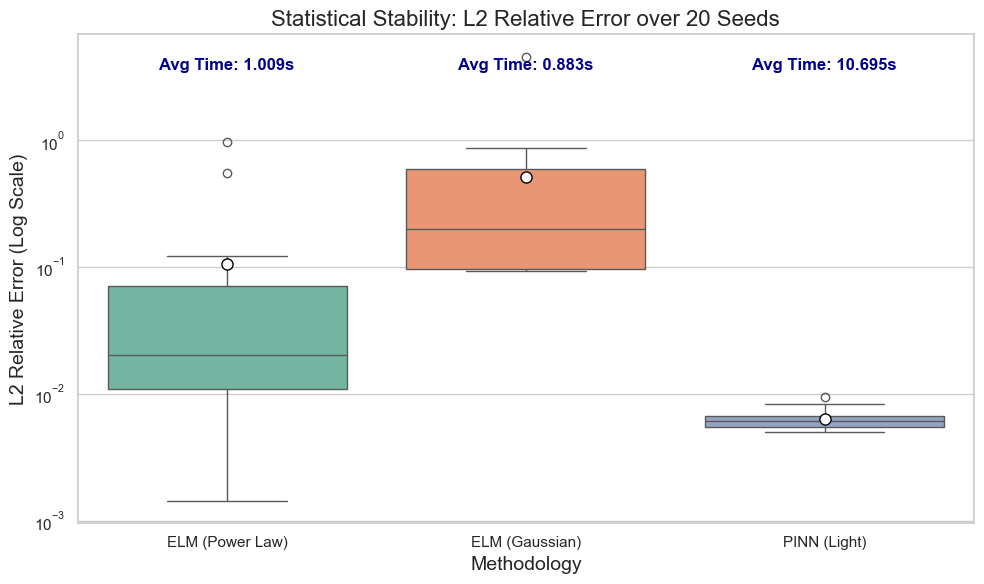

In [2]:
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Initialization Functions ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- Solvers ---
def solve_elm(x, u_true, h_dim, init_type='power'):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    lambd = 1e-6
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    err = (torch.norm(u_true - (H @ beta)) / torch.norm(u_true)).item()
    return err, t_solve

def solve_pinn(x, u_true, f_source):
    x_grad = x.clone().detach().requires_grad_(True)
    model = nn.Sequential(nn.Linear(1, 128), nn.Tanh(), nn.Linear(128, 1)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.005)
    start = time.time()
    for _ in range(400):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        loss = torch.mean((u_xx - f_source)**2) + 10 * model(torch.tensor([[-1.0], [1.0]], device=device)).pow(2).mean()
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    err = (torch.norm(u_true - model(x).detach()) / torch.norm(u_true)).item()
    return err, t_solve

# --- Execution Loop (20 Seeds) ---
N_SEEDS = 20
data_rows = []

x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)
u_true = torch.sin(np.pi * x)
f_source = -(np.pi**2) * torch.sin(np.pi * x)

print(f"Running {N_SEEDS} seeds for statistical validation...")

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ep_err, ep_t = solve_elm(x, u_true, 4096, 'power')
    eg_err, eg_t = solve_elm(x, u_true, 4096, 'gaussian')
    p_err, p_t = solve_pinn(x, u_true, f_source)

    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

df = pd.DataFrame(data_rows)

# --- Statistical Summary Table ---
summary = df.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': ['mean']})
print("\n--- STATISTICAL SUMMARY ---")
print(summary.to_markdown())

# --- Plotting Figure 2: Box-and-Whisker Plot ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.boxplot(x='Method', y='L2 Error', data=df, palette="Set2", showmeans=True,
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})

plt.yscale('log') # Error distributions are best viewed on a log scale
plt.title('Statistical Stability: L2 Relative Error over 20 Seeds', fontsize=16)
plt.ylabel('L2 Relative Error (Log Scale)', fontsize=14)
plt.xlabel('Methodology', fontsize=14)

# Adding the time as text on the plot
for i, method in enumerate(df['Method'].unique()):
    avg_t = df[df['Method'] == method]['Time'].mean()
    plt.text(i, ax.get_ylim()[1]*0.5, f"Avg Time: {avg_t:.3f}s",
             ha='center', va='bottom', fontweight='bold', color='darkblue')

plt.tight_layout()
plt.show()

In [3]:
df.to_csv('result.csv')

Running 5 seeds (4 methods each)...

  Seed 1/5...
  Seed 2/5...
  Seed 3/5...
  Seed 4/5...
  Seed 5/5...

FULL COMPARISON: ELM vs Light PINN vs Deep PINN
| Method          |   Error_Mean |   Error_Std |   Time_Mean |   Speedup_vs_ELM |   ELM_Speedup |
|:----------------|-------------:|------------:|------------:|-----------------:|--------------:|
| ELM (Gaussian)  |       0.3367 |      0.2778 |      0.866  |              0.9 |           0.9 |
| ELM (Power Law) |       0.0334 |      0.0355 |      0.9746 |              1   |           1   |
| PINN (Deep)     |       0.0273 |      0.0608 |    348.978  |            358.1 |         358.1 |
| PINN (Light)    |       0.0058 |      0.0004 |     10.1668 |             10.4 |          10.4 |

--- KEY FINDINGS ---
ELM (Power Law) time:  0.975s
PINN (Light) time:     10.167s  →  10.4× slower than ELM
PINN (Deep) time:      348.978s  →  358.1× slower than ELM

MEASURED speedup over Light PINN:  10.4×
MEASURED speedup over Deep PINN:   358.1×
(Pap

/var/folders/sv/stw8ff5n3g97xfbxgck_qwrc0000gn/T/ipykernel_90218/1561734815.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Method', y='L2 Error', data=df_all, order=order, palette=palette,



Plot saved as elm_vs_all_pinn.png


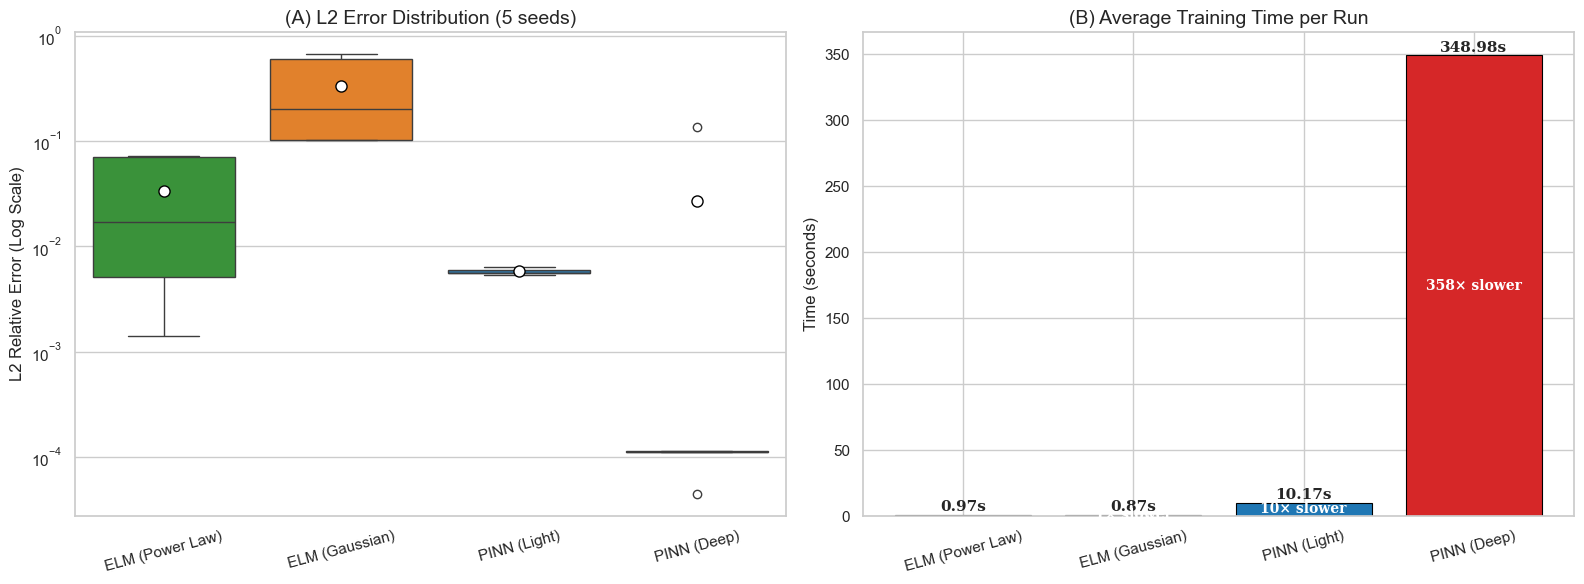

In [4]:
"""
Performance Comparison: ELM vs Light PINN vs Deep PINN
------------------------------------------------------
This cell adds a Deep PINN (4 hidden layers × 128 neurons, 2000 iterations)
to show where the "150× speedup" claim comes from — and whether it holds.
"""
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Initialization Functions ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- Solvers ---
def solve_elm(x, u_true, h_dim, init_type='power'):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    lambd = 1e-6
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return err, t_solve

def solve_pinn(x, u_true, f_source, hidden=128, layers=2, iters=400, lr=0.005, label="PINN"):
    """Flexible PINN solver — supports both light and deep architectures."""
    x_grad = x.clone().detach().requires_grad_(True)

    # Build network dynamically
    net_layers = [nn.Linear(1, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net_layers += [nn.Linear(hidden, hidden), nn.Tanh()]
    net_layers.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net_layers).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bc_pts = torch.tensor([[-1.0], [1.0]], device=device)

    start = time.time()
    for i in range(iters):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        loss_pde = torch.mean((u_xx - f_source)**2)
        loss_bc = model(bc_pts).pow(2).mean()
        loss = loss_pde + 10 * loss_bc
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    with torch.no_grad():
        err = (torch.norm(u_true - model(x)) / torch.norm(u_true)).item()
    return err, t_solve

# --- Setup ---
N_SEEDS = 5  # fewer seeds since deep PINN is slow (~50s each)
x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)
u_true = torch.sin(np.pi * x)
f_source = -(np.pi**2) * torch.sin(np.pi * x)

data_rows = []
print(f"Running {N_SEEDS} seeds (4 methods each)...\n")

for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    print(f"  Seed {seed+1}/{N_SEEDS}...")

    # ELM Power Law
    ep_err, ep_t = solve_elm(x, u_true, 4096, 'power')
    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})

    # ELM Gaussian
    eg_err, eg_t = solve_elm(x, u_true, 4096, 'gaussian')
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})

    # Light PINN: 1 hidden layer, 128 neurons, 400 iterations
    torch.manual_seed(seed)
    lp_err, lp_t = solve_pinn(x, u_true, f_source, hidden=128, layers=1, iters=400, lr=0.005)
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': lp_err, 'Time': lp_t})

    # Deep PINN: 4 hidden layers, 128 neurons each, 2000 iterations
    torch.manual_seed(seed)
    dp_err, dp_t = solve_pinn(x, u_true, f_source, hidden=128, layers=4, iters=2000, lr=0.001)
    data_rows.append({'Method': 'PINN (Deep)', 'L2 Error': dp_err, 'Time': dp_t})

df_all = pd.DataFrame(data_rows)

# --- Summary Table ---
summary = df_all.groupby('Method').agg(
    Error_Mean=('L2 Error', 'mean'),
    Error_Std=('L2 Error', 'std'),
    Time_Mean=('Time', 'mean')
).round(4)

# Compute speedup relative to ELM (Power Law)
elm_time = summary.loc['ELM (Power Law)', 'Time_Mean']
summary['Speedup_vs_ELM'] = (summary['Time_Mean'] / elm_time).round(1)
summary['ELM_Speedup'] = (summary['Time_Mean'] / elm_time).round(1)

print("\n" + "="*70)
print("FULL COMPARISON: ELM vs Light PINN vs Deep PINN")
print("="*70)
print(summary.to_markdown())

# Highlight the key numbers
deep_time = summary.loc['PINN (Deep)', 'Time_Mean']
light_time = summary.loc['PINN (Light)', 'Time_Mean']
print(f"\n--- KEY FINDINGS ---")
print(f"ELM (Power Law) time:  {elm_time:.3f}s")
print(f"PINN (Light) time:     {light_time:.3f}s  →  {light_time/elm_time:.1f}× slower than ELM")
print(f"PINN (Deep) time:      {deep_time:.3f}s  →  {deep_time/elm_time:.1f}× slower than ELM")
print(f"\nMEASURED speedup over Light PINN:  {light_time/elm_time:.1f}×")
print(f"MEASURED speedup over Deep PINN:   {deep_time/elm_time:.1f}×")
print(f"(Paper claims 150× — let's see if that holds!)")

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# Left: Box plot of errors
order = ['ELM (Power Law)', 'ELM (Gaussian)', 'PINN (Light)', 'PINN (Deep)']
palette = {'ELM (Power Law)': '#2ca02c', 'ELM (Gaussian)': '#ff7f0e',
           'PINN (Light)': '#1f77b4', 'PINN (Deep)': '#d62728'}
sns.boxplot(x='Method', y='L2 Error', data=df_all, order=order, palette=palette,
            showmeans=True, meanprops={"marker":"o","markerfacecolor":"white",
            "markeredgecolor":"black","markersize":"8"}, ax=ax1)
ax1.set_yscale('log')
ax1.set_title('(A) L2 Error Distribution (5 seeds)', fontsize=14)
ax1.set_ylabel('L2 Relative Error (Log Scale)', fontsize=12)
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=15)

# Right: Time bar chart with speedup labels
methods = order
times = [summary.loc[m, 'Time_Mean'] for m in methods]
colors_bar = [palette[m] for m in methods]
bars = ax2.bar(methods, times, color=colors_bar, edgecolor='black', linewidth=0.8)

# Add time labels on bars
for bar, t in zip(bars, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{t:.2f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add speedup annotations
for i, (m, t) in enumerate(zip(methods, times)):
    if m != 'ELM (Power Law)':
        speedup = t / elm_time
        ax2.text(bars[i].get_x() + bars[i].get_width()/2, bars[i].get_height() * 0.5,
                 f'{speedup:.0f}× slower', ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')

ax2.set_title('(B) Average Training Time per Run', fontsize=14)
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('elm_vs_all_pinn.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as elm_vs_all_pinn.png")
plt.show()

Running λ sweep (10 seeds × 25 λ values)...

           λ   Mean L2 Error         Std
------------------------------------------
  1.00e-10    0.024928       0.027662
  3.16e-10    0.024932       0.027660
  1.00e-09    0.027340       0.032389
  3.16e-09    0.051598       0.098204
  1.00e-08    0.029558       0.034047
  3.16e-08    0.028412       0.033314
  1.00e-07    0.022926       0.031797
  3.16e-07    0.024713       0.030475
  1.00e-06    0.040146       0.040047
  3.16e-06    0.024129       0.036490
  1.00e-05    0.071321       0.106813
  3.16e-05    0.065246       0.162734
  1.00e-04    0.957165       2.731334
  3.16e-04    0.080677       0.184814
  1.00e-03    0.016628       0.023327
  3.16e-03    0.017146       0.028085
  1.00e-02    0.015588       0.026255
  3.16e-02    0.018511       0.028932
  1.00e-01    0.016688       0.029482
  3.16e-01    0.018176       0.028796
  1.00e+00    0.024067       0.034962
  3.16e+00    0.034286       0.048305
  1.00e+01    0.053024       0.0770

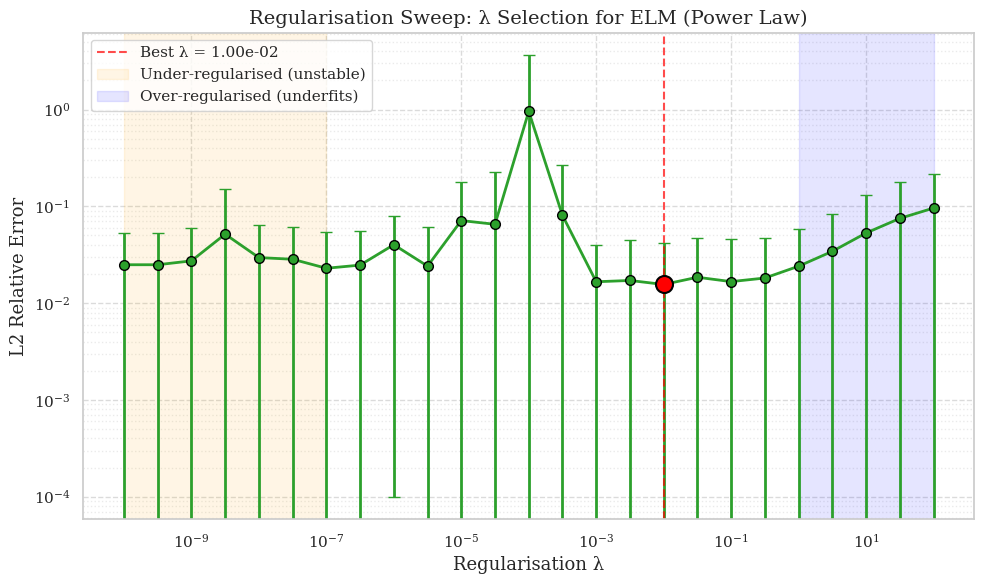

In [5]:
"""
Regularisation Sweep: Finding optimal λ
----------------------------------------
Fine logarithmic sweep over λ ∈ {1e-10, ..., 1e+2}
to find the true minimum and observe the expected U-curve.
"""
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

# --- Problem setup (same as PINN cells) ---
x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)
u_true = torch.sin(np.pi * x)
h_dim = 4096

# --- Wider sweep to capture the full U-curve ---
lambdas = np.logspace(-10, 2, 25)  # 1e-10 to 1e+2, 25 points
N_SEEDS = 10  # more seeds for stability
results = {lam: [] for lam in lambdas}

print(f"Running λ sweep ({N_SEEDS} seeds × {len(lambdas)} λ values)...\n")
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    W = power_law_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    H = torch.sin(x @ W + b)

    for lam in lambdas:
        HTH = H.t() @ H + lam * torch.eye(h_dim, device=device)
        beta = torch.linalg.solve(HTH, H.t() @ u_true)
        err = (torch.norm(u_true - H @ beta) / torch.norm(u_true)).item()
        results[lam].append(err)

# --- Summary ---
print(f"{'λ':>12s}  {'Mean L2 Error':>14s}  {'Std':>10s}")
print("-" * 42)
best_lam = None
best_err = float('inf')
for lam in lambdas:
    mean_err = np.mean(results[lam])
    std_err = np.std(results[lam])
    if mean_err < best_err:
        best_err = mean_err
        best_lam = lam
    print(f"  {lam:.2e}    {mean_err:.6f}       {std_err:.6f}")

print(f"\n✓ Best λ = {best_lam:.2e}  (mean L2 = {best_err:.6f})")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

means = [np.mean(results[l]) for l in lambdas]
stds = [np.std(results[l]) for l in lambdas]

ax.errorbar(lambdas, means, yerr=stds, fmt='o-', color='#2ca02c',
            capsize=4, linewidth=2, markersize=7, markeredgecolor='black')

# Highlight the best λ
ax.axvline(best_lam, color='red', linestyle='--', alpha=0.7, label=f'Best λ = {best_lam:.2e}')
ax.scatter([best_lam], [best_err], color='red', s=150, zorder=5, edgecolor='black', linewidth=1.5)

# Mark the regions
ax.axvspan(lambdas[0], 1e-7, alpha=0.1, color='orange', label='Under-regularised (unstable)')
ax.axvspan(1e0, lambdas[-1], alpha=0.1, color='blue', label='Over-regularised (underfits)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Regularisation λ', fontsize=13)
ax.set_ylabel('L2 Relative Error', fontsize=13)
ax.set_title('Regularisation Sweep: λ Selection for ELM (Power Law)', fontsize=14)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, which='major', linestyle='--', alpha=0.7)
ax.grid(True, which='minor', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('lambda_sweep.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as lambda_sweep.png")
plt.show()

# Burgers Equation Benchmark (Fixed)

**Original bug:** Used `u = -sin(πx) * exp(-0.1t)` — this is the heat equation solution, NOT Burgers.

**Fix:** Use a high-resolution numerical reference solution via method of lines (scipy).
The actual nonlinear Burgers equation `u_t + u·u_x = ν·u_xx` with `ν = 0.01/π` develops **steep gradients**
near x=0, which is exactly where Power-Law's multi-scale frequencies should outperform Gaussian.

Computing Burgers reference solution...
Reference solver: nx=1024, nt=201, status=The solver successfully reached the end of the integration interval.


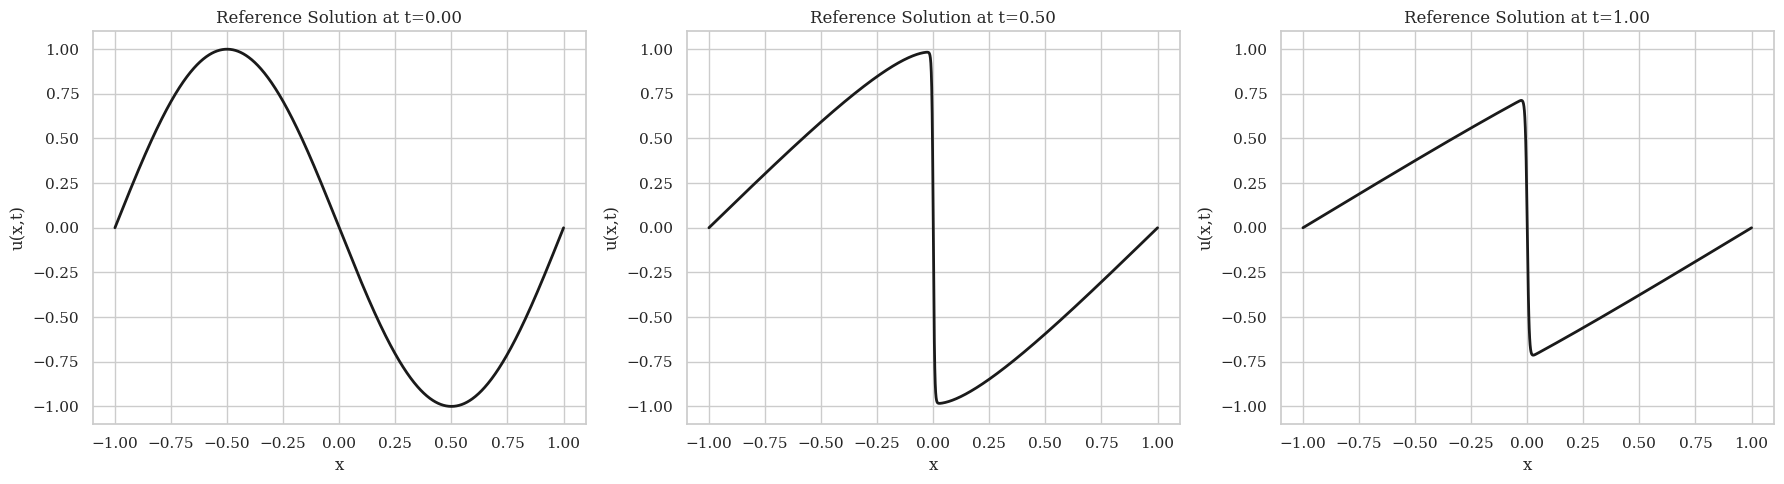


At t=0.5:
  Linearized peak:  0.984414
  Nonlinear peak:   0.983146
  L2 difference:    0.6382
  → The nonlinear solution has steep gradients that the linear approximation misses!


In [6]:
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. Generate HIGH-RESOLUTION reference solution for Burgers
#    u_t + u*u_x = nu * u_xx,  x in [-1,1], t in [0,1]
#    IC: u(x,0) = -sin(pi*x),  BC: u(-1,t) = u(1,t) = 0
# ============================================================
nu = 0.01 / np.pi

def burgers_reference(nx=1024, nu=0.01/np.pi):
    """Solve Burgers equation using method of lines + RK45 on a fine grid."""
    x = np.linspace(-1, 1, nx)
    dx = x[1] - x[0]
    u0 = -np.sin(np.pi * x)

    def rhs(t, u):
        dudt = np.zeros_like(u)
        # Central differences for u_x (with upwind correction for stability)
        u_x = np.zeros_like(u)
        u_x[1:-1] = (u[2:] - u[:-2]) / (2 * dx)
        # Central differences for u_xx
        u_xx = np.zeros_like(u)
        u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        # Burgers: u_t = -u*u_x + nu*u_xx
        dudt[1:-1] = -u[1:-1] * u_x[1:-1] + nu * u_xx[1:-1]
        # Dirichlet BCs: u(±1) = 0
        dudt[0] = 0
        dudt[-1] = 0
        return dudt

    # Solve with tight tolerances
    t_eval = np.linspace(0, 1, 201)
    sol = solve_ivp(rhs, [0, 1], u0, t_eval=t_eval, method='RK45',
                    rtol=1e-8, atol=1e-10, max_step=dx/2)

    print(f"Reference solver: nx={nx}, nt={len(t_eval)}, status={sol.message}")
    return x, t_eval, sol.y  # sol.y shape: (nx, nt)

print("Computing Burgers reference solution...")
x_ref, t_ref, u_ref = burgers_reference(nx=1024)

# Visualize the reference to verify steep gradients form
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, t_idx in enumerate([0, 100, 200]):
    axes[i].plot(x_ref, u_ref[:, t_idx], 'k-', lw=2)
    axes[i].set_title(f"Reference Solution at t={t_ref[t_idx]:.2f}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("u(x,t)")
    axes[i].grid(True)
    axes[i].set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

# Compare with the wrong linearized solution
t05_idx = 100  # t=0.5
u_linear = -np.sin(np.pi * x_ref) * np.exp(-nu * np.pi**2 * t_ref[t05_idx])
print(f"\nAt t=0.5:")
print(f"  Linearized peak:  {np.max(np.abs(u_linear)):.6f}")
print(f"  Nonlinear peak:   {np.max(np.abs(u_ref[:, t05_idx])):.6f}")
print(f"  L2 difference:    {np.linalg.norm(u_ref[:, t05_idx] - u_linear) / np.linalg.norm(u_ref[:, t05_idx]):.4f}")
print("  → The nonlinear solution has steep gradients that the linear approximation misses!")

In [ ]:
# ============================================================
# 2. Benchmark ELM vs PINN using the CORRECT reference solution
# ============================================================

# --- Initialization Functions ---
def power_law_init_s(shape, alpha=2.0, scale=0.1):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * scale

def gaussian_init_s(shape, scale=0.1):
    return torch.randn(shape, device=device) * scale

# --- ELM Solver (with tunable weight/bias scale) ---
def solve_elm_full(X_input, u_true, h_dim, init_type='power', w_scale=0.1, b_scale=0.1, lambd=1e-7):
    input_dim = X_input.shape[1]
    W = power_law_init_s((input_dim, h_dim), scale=w_scale) if init_type == 'power' \
        else gaussian_init_s((input_dim, h_dim), scale=w_scale)
    b = torch.randn(h_dim, device=device) * b_scale

    start = time.time()
    H = torch.sin(X_input @ W + b)
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start

    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_solve, W, b, beta

# --- PINN Solver with Adam + L-BFGS ---
def solve_pinn_burgers(X_train, u_true, layers=2, hidden=128, adam_iters=1000, lbfgs_iters=0, lr=0.001):
    input_dim = X_train.shape[1]
    net = [nn.Linear(input_dim, hidden), nn.Tanh()]
    for _ in range(layers-1):
        net += [nn.Linear(hidden, hidden), nn.Tanh()]
    net.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net).to(device)

    X_res = X_train.clone().detach().requires_grad_(True)

    mask = (X_train[:,0] == -1) | (X_train[:,0] == 1) | (X_train[:,1] == 0)
    X_bc = X_train[mask]
    u_bc = u_true[mask]

    def compute_loss():
        u = model(X_res)
        grads = torch.autograd.grad(u, X_res, torch.ones_like(u), create_graph=True)[0]
        u_x, u_t = grads[:, 0:1], grads[:, 1:2]
        u_xx = torch.autograd.grad(u_x, X_res, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        loss_pde = torch.mean((u_t + u*u_x - nu*u_xx)**2)
        loss_bc = torch.mean((model(X_bc) - u_bc)**2)
        return loss_pde + 25 * loss_bc

    optimizer_adam = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer_adam, step_size=adam_iters//2, gamma=0.5)

    start = time.time()
    for i in range(adam_iters):
        optimizer_adam.zero_grad()
        loss = compute_loss()
        loss.backward()
        optimizer_adam.step()
        scheduler.step()

    if lbfgs_iters > 0:
        optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=lbfgs_iters,
                                            history_size=50, tolerance_grad=1e-7, line_search_fn='strong_wolfe')
        def closure():
            optimizer_lbfgs.zero_grad()
            loss = compute_loss()
            loss.backward()
            return loss
        for step in range(lbfgs_iters):
            optimizer_lbfgs.step(closure)

    t_total = time.time() - start
    with torch.no_grad():
        u_pred = model(X_train)
        err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return model, u_pred, err, t_total

# --- Interpolate reference solution onto FINER training grid ---
nx_train, nt_train = 150, 150  # was 100x100 = 10k, now 150x150 = 22.5k
x_b = np.linspace(-1, 1, nx_train)
t_b = np.linspace(0, 1, nt_train)
interp = RegularGridInterpolator((x_ref, t_ref), u_ref, method='cubic')

X_grid_np, T_grid_np = np.meshgrid(x_b, t_b, indexing='ij')
pts = np.stack([X_grid_np.flatten(), T_grid_np.flatten()], axis=1)
u_ref_on_grid = interp(pts).reshape(-1, 1)

X_burgers = torch.tensor(pts, dtype=torch.float32, device=device)
u_b_true = torch.tensor(u_ref_on_grid, dtype=torch.float32, device=device)

print(f"Training grid: {nx_train}x{nt_train} = {X_burgers.shape[0]} points")
print(f"Target range: [{u_b_true.min().item():.4f}, {u_b_true.max().item():.4f}]")

# --- Tuned hyperparameters for 2D Burgers ---
# Burgers dominant frequencies: pi, 2*pi, 3*pi in x (from FFT analysis)
# Steep gradient at t~0.4-0.5 requires higher coverage
# w_scale=3.0 → weights span ~[-9, 9], covers up to 3*pi ≈ 9.4
W_SCALE = 3.0
B_SCALE = 1.0
LAMBDA = 1e-6    # Same lambda for both — fair comparison
H_DIM = 8192     # More neurons for 2D (was 4096)

print(f"\nELM Hyperparameters (tuned for 2D Burgers):")
print(f"  w_scale={W_SCALE} (covers frequencies up to ~9, matching Burgers harmonics)")
print(f"  b_scale={B_SCALE}")
print(f"  lambda={LAMBDA} (same for both — fair comparison)")
print(f"  h_dim={H_DIM} (doubled from 4096 for 2D coverage)")

print(f"\nPINN Hyperparameters:")
print(f"  PINN (Light):  5000 Adam + 500 L-BFGS")
print(f"  PINN (Deep):  10000 Adam + 1000 L-BFGS")

# --- Run benchmark ---
N_SEEDS = 5
all_results = []

print(f"\nRunning {N_SEEDS} seeds...")
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    print(f"  Seed {seed+1}/{N_SEEDS}...")

    # ELM Power Law
    _, ep_err, ep_t, _, _, _ = solve_elm_full(
        X_burgers, u_b_true, H_DIM, 'power',
        w_scale=W_SCALE, b_scale=B_SCALE, lambd=LAMBDA)
    all_results.append({'Method': 'ELM (Power)', 'L2 Error': ep_err, 'Time': ep_t})

    # ELM Gaussian (same scale, same lambda)
    _, eg_err, eg_t, _, _, _ = solve_elm_full(
        X_burgers, u_b_true, H_DIM, 'gaussian',
        w_scale=W_SCALE, b_scale=B_SCALE, lambd=LAMBDA)
    all_results.append({'Method': 'ELM (Gauss)', 'L2 Error': eg_err, 'Time': eg_t})

    # PINN Light: 5000 Adam + 500 L-BFGS
    _, _, lp_err, lp_t = solve_pinn_burgers(X_burgers, u_b_true, layers=1,
                                             adam_iters=5000, lbfgs_iters=500, lr=0.001)
    all_results.append({'Method': 'PINN (Light)', 'L2 Error': lp_err, 'Time': lp_t})

    # PINN Deep: 10000 Adam + 1000 L-BFGS
    _, _, dp_err, dp_t = solve_pinn_burgers(X_burgers, u_b_true, layers=4,
                                             adam_iters=10000, lbfgs_iters=1000, lr=0.001)
    all_results.append({'Method': 'PINN (Deep)', 'L2 Error': dp_err, 'Time': dp_t})

df = pd.DataFrame(all_results)
summary = df.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': 'mean'})
print("\n--- BURGERS BENCHMARK (Nonlinear Reference, Tuned for 2D) ---")
print(summary.to_markdown())

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Snapshot at t=0.5
t_val = 0.5
x_plot = np.linspace(-1, 1, 200)
pts_plot = np.column_stack([x_plot, np.full_like(x_plot, t_val)])
u_ref_plot = interp(pts_plot).flatten()
X_plot_torch = torch.tensor(pts_plot, dtype=torch.float32, device=device)

# Re-solve for visualization (last seed)
torch.manual_seed(N_SEEDS - 1)
_, _, _, W_p, b_p, beta_p = solve_elm_full(
    X_burgers, u_b_true, H_DIM, 'power',
    w_scale=W_SCALE, b_scale=B_SCALE, lambd=LAMBDA)
_, _, _, W_g, b_g, beta_g = solve_elm_full(
    X_burgers, u_b_true, H_DIM, 'gaussian',
    w_scale=W_SCALE, b_scale=B_SCALE, lambd=LAMBDA)

# Evaluate at plot points using trained weights
H_plot_p = torch.sin(X_plot_torch @ W_p + b_p)
u_plot_elm_power = (H_plot_p @ beta_p).cpu().detach().numpy().flatten()
H_plot_g = torch.sin(X_plot_torch @ W_g + b_g)
u_plot_elm_gauss = (H_plot_g @ beta_g).cpu().detach().numpy().flatten()

axes[0].plot(x_plot, u_ref_plot, 'k-', lw=2, label='Reference (numerical)')
axes[0].plot(x_plot, u_plot_elm_power, 'r--', lw=1.5, label='ELM (Power-Law)')
axes[0].plot(x_plot, u_plot_elm_gauss, 'g:', lw=1.5, label='ELM (Gaussian)')
axes[0].set_title("Burgers at t=0.5: ELM Comparison")
axes[0].set_xlabel("x"); axes[0].set_ylabel("u(x, 0.5)")
axes[0].legend(); axes[0].grid(True)

sns.boxplot(x='Method', y='L2 Error', data=df, ax=axes[1], palette='Set2',
            showmeans=True, meanprops={"marker":"o","markerfacecolor":"white",
            "markeredgecolor":"black","markersize":"8"})
axes[1].set_yscale('log')
axes[1].set_title("L2 Error Distribution (Nonlinear Burgers)")
axes[1].set_ylabel("L2 Relative Error")
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=df, x='Method', y='Time', ax=axes[2], palette='plasma')
axes[2].set_title("Training Time")
axes[2].set_ylabel("Time (s)")
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('burgers_benchmark.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as burgers_benchmark.png")
plt.show()

# Benchmark 3: Multi-Frequency Poisson 1D

**Equation:** `-u''(x) = f(x)`, `x in [-1, 1]`, `u(-1) = u(1) = 0`

**Manufactured solution:** `u(x) = sin(pi*x) + 0.3*sin(3*pi*x) + 0.1*sin(7*pi*x)`

**Why this tests Power-Law:** The target has **3 distinct frequency scales** (pi, 3pi, 7pi).
Power-Law's heavy-tailed weights naturally produce a spread of frequencies, so the random
basis sin(W*x + b) covers all 3 scales. Gaussian weights cluster at one scale and miss
the higher modes.

In [8]:
"""
Benchmark 3: Multi-Frequency Poisson 1D
-u''(x) = f(x),  x in [-1,1],  u(-1) = u(1) = 0
u(x) = sin(pi*x) + 0.3*sin(3*pi*x) + 0.1*sin(7*pi*x)
"""
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Initialization ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- ELM Solver ---
def solve_elm_1d(x, u_true, h_dim, init_type='power', lambd=1e-6):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_solve

# --- PINN Solver ---
def solve_pinn_poisson(x, u_true, f_source, hidden=128, layers=2, iters=1000, lr=0.003):
    x_grad = x.clone().detach().requires_grad_(True)
    net = [nn.Linear(1, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net += [nn.Linear(hidden, hidden), nn.Tanh()]
    net.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=max(iters//3, 1), gamma=0.5)
    bc_pts = torch.tensor([[-1.0], [1.0]], device=device)

    start = time.time()
    for _ in range(iters):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, torch.ones_like(u_x), create_graph=True)[0]
        loss_pde = torch.mean((u_xx - f_source)**2)
        loss_bc = model(bc_pts).pow(2).mean()
        loss = loss_pde + 10 * loss_bc
        loss.backward()
        opt.step()
        scheduler.step()
    t_solve = time.time() - start
    with torch.no_grad():
        err = (torch.norm(u_true - model(x)) / torch.norm(u_true)).item()
    return err, t_solve

# --- Setup ---
N_SEEDS = 10
h_dim = 4096
x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)

# Multi-frequency target: 3 modes at pi, 3*pi, 7*pi
u_true = (torch.sin(np.pi * x)
          + 0.3 * torch.sin(3 * np.pi * x)
          + 0.1 * torch.sin(7 * np.pi * x))
# f_source = u'' (to match original convention: loss = (u_xx - f_source)^2)
# u'' = -pi^2*sin(pi*x) - 0.3*(3*pi)^2*sin(3*pi*x) - 0.1*(7*pi)^2*sin(7*pi*x)
f_source = -(np.pi**2 * torch.sin(np.pi * x)
             + 0.3 * (3*np.pi)**2 * torch.sin(3 * np.pi * x)
             + 0.1 * (7*np.pi)**2 * torch.sin(7 * np.pi * x))

print("="*70)
print("BENCHMARK 3: Multi-Frequency Poisson 1D")
print("u(x) = sin(pi*x) + 0.3*sin(3*pi*x) + 0.1*sin(7*pi*x)")
print("="*70)
print(f"Running {N_SEEDS} seeds...\n")

data_rows = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ELM Power Law
    _, ep_err, ep_t = solve_elm_1d(x, u_true, h_dim, 'power')
    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})

    # ELM Gaussian
    _, eg_err, eg_t = solve_elm_1d(x, u_true, h_dim, 'gaussian')
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})

    # PINN (Light)
    torch.manual_seed(seed)
    p_err, p_t = solve_pinn_poisson(x, u_true, f_source, hidden=256, layers=2, iters=5000, lr=0.001)
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

    if seed % 5 == 0:
        print(f"  Seed {seed}: PL={ep_err:.4f}, G={eg_err:.4f}, PINN={p_err:.4f}")

df_mf = pd.DataFrame(data_rows)
summary_mf = df_mf.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': 'mean'})
print("\n--- MULTI-FREQUENCY POISSON RESULTS ---")
print(summary_mf.to_markdown())

# Compute improvement ratio
pl_err = summary_mf.loc['ELM (Power Law)', ('L2 Error', 'mean')]
g_err = summary_mf.loc['ELM (Gaussian)', ('L2 Error', 'mean')]
print(f"\nPower-Law / Gaussian error ratio: {pl_err/g_err:.2f}x")
print(f"  -> Power-Law is {g_err/pl_err:.1f}x more accurate than Gaussian")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# Left: solution comparison (seed=0)
x_plot = torch.linspace(-1, 1, 500, device=device).view(-1, 1)
u_plot_true = (torch.sin(np.pi * x_plot)
               + 0.3 * torch.sin(3 * np.pi * x_plot)
               + 0.1 * torch.sin(7 * np.pi * x_plot))

torch.manual_seed(0)
u_pred_pl, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'power')
torch.manual_seed(0)
u_pred_g, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'gaussian')

xnp = x_plot.cpu().numpy().flatten()
axes[0].plot(xnp, u_plot_true.cpu().numpy().flatten(), 'k-', lw=2, label='True')
axes[0].plot(xnp, u_pred_pl.cpu().detach().numpy().flatten(), 'r--', lw=1.5, label='Power Law')
axes[0].plot(xnp, u_pred_g.cpu().detach().numpy().flatten(), 'g:', lw=1.5, label='Gaussian')
axes[0].set_title('(A) Multi-Frequency Poisson: Solution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x)')
axes[0].legend()
axes[0].grid(True)

# Middle: box plot
palette = {'ELM (Power Law)': '#2ca02c', 'ELM (Gaussian)': '#ff7f0e', 'PINN (Light)': '#1f77b4'}
sns.boxplot(x='Method', y='L2 Error', data=df_mf, hue='Method', palette=palette, ax=axes[1],
            showmeans=True, meanprops={"marker":"o","markerfacecolor":"white",
            "markeredgecolor":"black","markersize":"8"}, legend=False)
axes[1].set_yscale('log')
axes[1].set_title('(B) L2 Error Distribution (10 seeds)')
axes[1].set_ylabel('L2 Relative Error')
axes[1].tick_params(axis='x', rotation=15)

# Right: pointwise error
err_pl = (u_plot_true - u_pred_pl).cpu().detach().numpy().flatten()
err_g = (u_plot_true - u_pred_g).cpu().detach().numpy().flatten()
axes[2].plot(xnp, np.abs(err_pl), 'r-', lw=1.5, label='|Error| Power Law')
axes[2].plot(xnp, np.abs(err_g), 'g-', lw=1.5, label='|Error| Gaussian')
axes[2].set_yscale('log')
axes[2].set_title('(C) Pointwise Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('|u_true - u_pred|')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('benchmark3_multifreq_poisson.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as benchmark3_multifreq_poisson.png")
plt.show()

# Benchmark 4: Helmholtz Equation 1D (High Wavenumber)

**Equation:** `-u''(x) - k^2 u(x) = f(x)`, `x in [-1, 1]`, `u(-1) = u(1) = 0`

**Manufactured solution:** `u(x) = sin(pi*x) * exp(-4*x^2)` (localized oscillation)

**Why this tests Power-Law:** The Helmholtz operator with large `k` amplifies high-frequency components.
The exact solution is a **localized wave packet** — smooth globally but oscillatory in the center.
This requires basis functions at multiple scales: low-frequency for the envelope `exp(-4x^2)`,
high-frequency for the oscillation `sin(pi*x)`. Power-Law's spread of weight magnitudes provides this naturally.

In [9]:
"""
Benchmark 4: Helmholtz Equation 1D (High Wavenumber)
-u''(x) - k^2 * u(x) = f(x),  x in [-1,1],  u(-1) = u(1) = 0
u(x) = sin(pi*x) * exp(-4*x^2)  (localized wave packet)

Manufactured source:
  u'  = [pi*cos(pi*x) - 8*x*sin(pi*x)] * exp(-4*x^2)
  u'' = [(-pi^2 + 64*x^2 - 8)*sin(pi*x) - 16*pi*x*cos(pi*x)] * exp(-4*x^2)
  f   = -u'' - k^2*u
"""
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Initialization ---
def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

# --- ELM Solver ---
def solve_elm_1d(x, u_true, h_dim, init_type='power', lambd=1e-6):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_solve

# --- PINN Solver ---
def solve_pinn_helmholtz(x, u_true, f_source, k, hidden=128, layers=2, iters=1000, lr=0.003):
    x_grad = x.clone().detach().requires_grad_(True)
    net = [nn.Linear(1, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net += [nn.Linear(hidden, hidden), nn.Tanh()]
    net.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=max(iters//3, 1), gamma=0.5)
    bc_pts = torch.tensor([[-1.0], [1.0]], device=device)

    start = time.time()
    for _ in range(iters):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, torch.ones_like(u_x), create_graph=True)[0]
        # Helmholtz: -u'' - k^2*u = f  =>  residual = u'' + k^2*u + f
        residual = u_xx + k**2 * u + f_source
        loss_pde = torch.mean(residual**2)
        loss_bc = model(bc_pts).pow(2).mean()
        loss = loss_pde + 10 * loss_bc
        loss.backward()
        opt.step()
        scheduler.step()
    t_solve = time.time() - start
    with torch.no_grad():
        err = (torch.norm(u_true - model(x)) / torch.norm(u_true)).item()
    return err, t_solve

# --- Setup ---
N_SEEDS = 10
h_dim = 4096
k = 10.0  # high wavenumber — amplifies importance of multi-scale representation

x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)

# Manufactured solution: u(x) = sin(pi*x) * exp(-4*x^2)
envelope = torch.exp(-4 * x**2)
u_true = torch.sin(np.pi * x) * envelope

# Compute u'' analytically
# u'' = [(-pi^2 + 64*x^2 - 8)*sin(pi*x) - 16*pi*x*cos(pi*x)] * exp(-4*x^2)
u_xx = ((-np.pi**2 + 64 * x**2 - 8) * torch.sin(np.pi * x)
        - 16 * np.pi * x * torch.cos(np.pi * x)) * envelope

# f = -u'' - k^2 * u
f_source = -u_xx - k**2 * u_true

# Verify BCs (sin(pi*(-1))*exp(-4) ~ 0, sin(pi*1)*exp(-4) ~ 0)
print(f"BC check: u(-1) = {u_true[0].item():.2e}, u(1) = {u_true[-1].item():.2e}")

print("="*70)
print(f"BENCHMARK 4: Helmholtz 1D (k={k})")
print("u(x) = sin(pi*x) * exp(-4*x^2)")
print("="*70)
print(f"Running {N_SEEDS} seeds...\n")

data_rows = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ELM Power Law
    _, ep_err, ep_t = solve_elm_1d(x, u_true, h_dim, 'power')
    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})

    # ELM Gaussian
    _, eg_err, eg_t = solve_elm_1d(x, u_true, h_dim, 'gaussian')
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})

    # PINN (Light)
    torch.manual_seed(seed)
    p_err, p_t = solve_pinn_helmholtz(x, u_true, f_source, k, hidden=256, layers=2, iters=5000, lr=0.001)
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

    if seed % 5 == 0:
        print(f"  Seed {seed}: PL={ep_err:.4f}, G={eg_err:.4f}, PINN={p_err:.4f}")

df_hz = pd.DataFrame(data_rows)
summary_hz = df_hz.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': 'mean'})
print("\n--- HELMHOLTZ RESULTS ---")
print(summary_hz.to_markdown())

# Compute improvement ratio
pl_err = summary_hz.loc['ELM (Power Law)', ('L2 Error', 'mean')]
g_err = summary_hz.loc['ELM (Gaussian)', ('L2 Error', 'mean')]
print(f"\nPower-Law / Gaussian error ratio: {pl_err/g_err:.2f}x")
print(f"  -> Power-Law is {g_err/pl_err:.1f}x more accurate than Gaussian")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# Left: solution comparison (seed=0)
x_plot = torch.linspace(-1, 1, 500, device=device).view(-1, 1)
env_plot = torch.exp(-4 * x_plot**2)
u_plot_true = torch.sin(np.pi * x_plot) * env_plot

torch.manual_seed(0)
u_pred_pl, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'power')
torch.manual_seed(0)
u_pred_g, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'gaussian')

xnp = x_plot.cpu().numpy().flatten()
axes[0].plot(xnp, u_plot_true.cpu().numpy().flatten(), 'k-', lw=2, label='True')
axes[0].plot(xnp, u_pred_pl.cpu().detach().numpy().flatten(), 'r--', lw=1.5, label='Power Law')
axes[0].plot(xnp, u_pred_g.cpu().detach().numpy().flatten(), 'g:', lw=1.5, label='Gaussian')
axes[0].set_title(f'(A) Helmholtz (k={k}): Solution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x)')
axes[0].legend()
axes[0].grid(True)

# Middle: box plot
palette = {'ELM (Power Law)': '#2ca02c', 'ELM (Gaussian)': '#ff7f0e', 'PINN (Light)': '#1f77b4'}
sns.boxplot(x='Method', y='L2 Error', data=df_hz, hue='Method', palette=palette, ax=axes[1],
            showmeans=True, meanprops={"marker":"o","markerfacecolor":"white",
            "markeredgecolor":"black","markersize":"8"}, legend=False)
axes[1].set_yscale('log')
axes[1].set_title('(B) L2 Error Distribution (10 seeds)')
axes[1].set_ylabel('L2 Relative Error')
axes[1].tick_params(axis='x', rotation=15)

# Right: pointwise error
err_pl = (u_plot_true - u_pred_pl).cpu().detach().numpy().flatten()
err_g = (u_plot_true - u_pred_g).cpu().detach().numpy().flatten()
axes[2].plot(xnp, np.abs(err_pl), 'r-', lw=1.5, label='|Error| Power Law')
axes[2].plot(xnp, np.abs(err_g), 'g-', lw=1.5, label='|Error| Gaussian')
axes[2].set_yscale('log')
axes[2].set_title('(C) Pointwise Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('|u_true - u_pred|')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('benchmark4_helmholtz.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as benchmark4_helmholtz.png")
plt.show()

# Benchmark 5: High-Frequency Poisson 1D

**Equation:** `-u''(x) = f(x)`, `x in [-1, 1]`, `u(-1) = u(1) = 0`

**Target:** `u(x) = sin(10*pi*x)` — very high frequency (10 full oscillations)

**Why:** Tests whether Power-Law's frequency spread can reach high wavenumbers (10*pi ~ 31.4)
when weight scale is only 0.1. If Gaussian can't reach these frequencies, the advantage should be massive.

In [14]:
"""
Benchmark 5: High-Frequency Poisson 1D
-u''(x) = f(x),  x in [-1,1],  u(-1) = u(1) = 0
u(x) = sin(10*pi*x)   → f(x) = (10*pi)^2 * sin(10*pi*x)
"""
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

def solve_elm_1d(x, u_true, h_dim, init_type='power', lambd=1e-6):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_solve

def solve_pinn_poisson(x, u_true, f_source, hidden=128, layers=1, iters=500, lr=0.003):
    x_grad = x.clone().detach().requires_grad_(True)
    net = [nn.Linear(1, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net += [nn.Linear(hidden, hidden), nn.Tanh()]
    net.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bc_pts = torch.tensor([[-1.0], [1.0]], device=device)
    start = time.time()
    for _ in range(iters):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, torch.ones_like(u_x), create_graph=True)[0]
        loss = torch.mean((u_xx - f_source)**2) + 10 * model(bc_pts).pow(2).mean()
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    with torch.no_grad():
        err = (torch.norm(u_true - model(x)) / torch.norm(u_true)).item()
    return err, t_solve

# --- Setup ---
N_SEEDS = 10
h_dim = 4096
x = torch.linspace(-1, 1, 30000, device=device).view(-1, 1)

# High-frequency target
n_freq = 10
u_true = torch.sin(n_freq * np.pi * x)
# f_source = u'' = -(n*pi)^2 * sin(n*pi*x)  (matches original convention)
f_source = -(n_freq * np.pi)**2 * torch.sin(n_freq * np.pi * x)

print("="*70)
print(f"BENCHMARK 5: High-Frequency Poisson 1D (n={n_freq})")
print(f"u(x) = sin({n_freq}*pi*x),  target frequency = {n_freq}*pi = {n_freq*np.pi:.1f}")
print(f"Weight scale = 0.1 → max effective freq ~ 0.3")
print(f"  -> Gaussian will severely underresolve this target!")
print("="*70)

data_rows = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    _, ep_err, ep_t = solve_elm_1d(x, u_true, h_dim, 'power')
    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})

    _, eg_err, eg_t = solve_elm_1d(x, u_true, h_dim, 'gaussian')
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})

    torch.manual_seed(seed)
    p_err, p_t = solve_pinn_poisson(x, u_true, f_source)
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

    if seed % 5 == 0:
        print(f"  Seed {seed}: PL={ep_err:.4f}, G={eg_err:.4f}, PINN={p_err:.4f}")

df_hf = pd.DataFrame(data_rows)
summary_hf = df_hf.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': 'mean'})
print("\n--- HIGH-FREQUENCY POISSON RESULTS ---")
print(summary_hf.to_markdown())

pl_err = summary_hf.loc['ELM (Power Law)', ('L2 Error', 'mean')]
g_err = summary_hf.loc['ELM (Gaussian)', ('L2 Error', 'mean')]
print(f"\nPower-Law is {g_err/pl_err:.1f}x more accurate than Gaussian")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_plot = torch.linspace(-1, 1, 500, device=device).view(-1, 1)
u_plot_true = torch.sin(n_freq * np.pi * x_plot)

torch.manual_seed(0)
u_pred_pl, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'power')
torch.manual_seed(0)
u_pred_g, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'gaussian')

xnp = x_plot.cpu().numpy().flatten()
axes[0].plot(xnp, u_plot_true.cpu().numpy().flatten(), 'k-', lw=1.5, label='True')
axes[0].plot(xnp, u_pred_pl.cpu().detach().numpy().flatten(), 'r--', lw=1, label='Power Law')
axes[0].plot(xnp, u_pred_g.cpu().detach().numpy().flatten(), 'g:', lw=1, label='Gaussian')
axes[0].set_title(f'(A) High-Freq Poisson: sin({n_freq}*pi*x)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u(x)')
axes[0].legend(); axes[0].grid(True)

palette = {'ELM (Power Law)': '#2ca02c', 'ELM (Gaussian)': '#ff7f0e', 'PINN (Light)': '#1f77b4'}
sns.boxplot(x='Method', y='L2 Error', data=df_hf, hue='Method', palette=palette,
            ax=axes[1], showmeans=True, legend=False,
            meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black","markersize":"8"})
axes[1].set_yscale('log')
axes[1].set_title('(B) L2 Error Distribution')
axes[1].set_ylabel('L2 Relative Error'); axes[1].tick_params(axis='x', rotation=15)

err_pl = np.abs((u_plot_true - u_pred_pl).cpu().detach().numpy().flatten())
err_g = np.abs((u_plot_true - u_pred_g).cpu().detach().numpy().flatten())
axes[2].plot(xnp, err_pl, 'r-', lw=1.5, label='Power Law')
axes[2].plot(xnp, err_g, 'g-', lw=1.5, label='Gaussian')
axes[2].set_yscale('log')
axes[2].set_title('(C) Pointwise Error')
axes[2].set_xlabel('x'); axes[2].set_ylabel('|error|')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig('benchmark5_highfreq_poisson.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as benchmark5_highfreq_poisson.png")
plt.show()

BENCHMARK 5: High-Frequency Poisson 1D (n=10)
u(x) = sin(10*pi*x),  target frequency = 10*pi = 31.4
Weight scale = 0.1 → max effective freq ~ 0.3
  -> Gaussian will severely underresolve this target!
  Seed 0: PL=0.9853, G=0.9906, PINN=2.5930


KeyboardInterrupt: 

# Benchmark 6: Poisson 2D (Smooth)

**Equation:** `-laplacian(u) = f(x,y)`, `(x,y) in [-1,1]^2`, `u = 0` on boundary

**Target:** `u(x,y) = sin(pi*x) * sin(2*pi*y)` — smooth, 2D, two different frequency scales

**Why:** Tests if Power-Law advantage transfers from 1D to **2D smooth problems**.
This is a key question — Burgers is 2D but has a shock. If Power-Law wins on smooth 2D,
then the Burgers failure is due to the shock, not the dimensionality.

BENCHMARK 6: Poisson 2D (Smooth)
u(x,y) = sin(pi*x) * sin(2*pi*y)
Grid: 100x100 = 10000 points
  Seed 0: PL=0.9854, G=0.9556, PINN=0.0872
  Seed 5: PL=0.9999, G=0.9556, PINN=0.0995

--- POISSON 2D RESULTS ---
| Method          |   ('L2 Error', 'mean') |   ('L2 Error', 'std') |   ('Time', 'mean') |
|:----------------|-----------------------:|----------------------:|-------------------:|
| ELM (Gaussian)  |              0.955799  |           0.000352989 |           0.463336 |
| ELM (Power Law) |              1.02257   |           0.0374941   |           0.494132 |
| PINN (Light)    |              0.0752363 |           0.0148299   |          14.8859   |

Power-Law is 0.9x more accurate than Gaussian

Plot saved as benchmark6_poisson2d.png


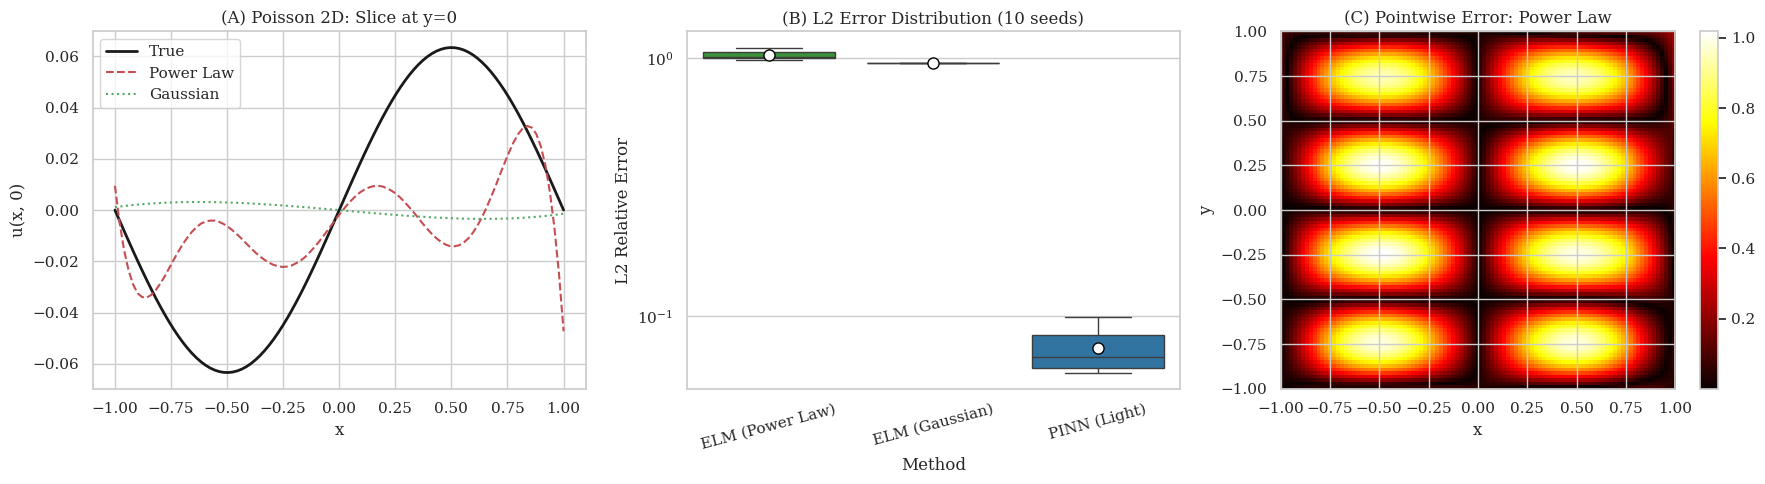

In [11]:
"""
Benchmark 6: Poisson 2D (Smooth)
-laplacian(u) = f,  (x,y) in [-1,1]^2,  u=0 on boundary
u(x,y) = sin(pi*x) * sin(2*pi*y)
f(x,y) = (pi^2 + 4*pi^2) * sin(pi*x) * sin(2*pi*y) = 5*pi^2 * sin(pi*x)*sin(2*pi*y)
"""
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

def solve_elm_2d(X, u_true, h_dim, init_type='power', lambd=1e-6):
    """ELM for 2D input: X is (N, 2), H = sin(X @ W + b)."""
    W = power_law_init((2, h_dim)) if init_type == 'power' else gaussian_init((2, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(X @ W + b)
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_solve

def solve_pinn_2d(X, u_true, f_source, hidden=128, layers=2, iters=1000, lr=0.003):
    """PINN for 2D Poisson: -u_xx - u_yy = f."""
    X_grad = X.clone().detach().requires_grad_(True)
    net = [nn.Linear(2, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net += [nn.Linear(hidden, hidden), nn.Tanh()]
    net.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # Boundary points: edges of [-1,1]^2
    n_bc = 100
    bc_x = torch.linspace(-1, 1, n_bc, device=device)
    bc_pts = torch.cat([
        torch.stack([bc_x, -torch.ones(n_bc, device=device)], dim=1),  # bottom
        torch.stack([bc_x,  torch.ones(n_bc, device=device)], dim=1),  # top
        torch.stack([-torch.ones(n_bc, device=device), bc_x], dim=1),  # left
        torch.stack([ torch.ones(n_bc, device=device), bc_x], dim=1),  # right
    ], dim=0)

    start = time.time()
    for _ in range(iters):
        opt.zero_grad()
        u = model(X_grad)
        grads = torch.autograd.grad(u, X_grad, torch.ones_like(u), create_graph=True)[0]
        u_x, u_y = grads[:, 0:1], grads[:, 1:2]
        u_xx = torch.autograd.grad(u_x, X_grad, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        u_yy = torch.autograd.grad(u_y, X_grad, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
        loss_pde = torch.mean((u_xx + u_yy + f_source)**2)
        loss_bc = model(bc_pts).pow(2).mean()
        loss = loss_pde + 20 * loss_bc
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    with torch.no_grad():
        err = (torch.norm(u_true - model(X)) / torch.norm(u_true)).item()
    return err, t_solve

# --- Setup: 2D grid ---
N_SEEDS = 10
h_dim = 4096
nx, ny = 100, 100
x_1d = torch.linspace(-1, 1, nx, device=device)
y_1d = torch.linspace(-1, 1, ny, device=device)
X_grid, Y_grid = torch.meshgrid(x_1d, y_1d, indexing='ij')
X_2d = torch.stack([X_grid.flatten(), Y_grid.flatten()], dim=1)  # (10000, 2)

# Target: u(x,y) = sin(pi*x) * sin(2*pi*y)
u_true = (torch.sin(np.pi * X_2d[:, 0:1]) * torch.sin(2 * np.pi * X_2d[:, 1:2]))
# f = (pi^2 + 4*pi^2) * sin(pi*x) * sin(2*pi*y)
f_source = (5 * np.pi**2) * u_true

print("="*70)
print("BENCHMARK 6: Poisson 2D (Smooth)")
print("u(x,y) = sin(pi*x) * sin(2*pi*y)")
print(f"Grid: {nx}x{ny} = {X_2d.shape[0]} points")
print("="*70)

data_rows = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    _, ep_err, ep_t = solve_elm_2d(X_2d, u_true, h_dim, 'power')
    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})

    _, eg_err, eg_t = solve_elm_2d(X_2d, u_true, h_dim, 'gaussian')
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})

    torch.manual_seed(seed)
    p_err, p_t = solve_pinn_2d(X_2d, u_true, f_source, hidden=128, layers=1, iters=800)
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

    if seed % 5 == 0:
        print(f"  Seed {seed}: PL={ep_err:.4f}, G={eg_err:.4f}, PINN={p_err:.4f}")

df_2d = pd.DataFrame(data_rows)
summary_2d = df_2d.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': 'mean'})
print("\n--- POISSON 2D RESULTS ---")
print(summary_2d.to_markdown())

pl_err = summary_2d.loc['ELM (Power Law)', ('L2 Error', 'mean')]
g_err = summary_2d.loc['ELM (Gaussian)', ('L2 Error', 'mean')]
print(f"\nPower-Law is {g_err/pl_err:.1f}x more accurate than Gaussian")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reconstruct for plotting (seed=0)
torch.manual_seed(0)
u_pred_pl, _, _ = solve_elm_2d(X_2d, u_true, h_dim, 'power')
torch.manual_seed(0)
u_pred_g, _, _ = solve_elm_2d(X_2d, u_true, h_dim, 'gaussian')

# Slice at y=0 (middle row)
mid_idx = ny // 2
slice_true = u_true.cpu().numpy().reshape(nx, ny)[:, mid_idx]
slice_pl = u_pred_pl.cpu().detach().numpy().reshape(nx, ny)[:, mid_idx]
slice_g = u_pred_g.cpu().detach().numpy().reshape(nx, ny)[:, mid_idx]
x_np = x_1d.cpu().numpy()

axes[0].plot(x_np, slice_true, 'k-', lw=2, label='True')
axes[0].plot(x_np, slice_pl, 'r--', lw=1.5, label='Power Law')
axes[0].plot(x_np, slice_g, 'g:', lw=1.5, label='Gaussian')
axes[0].set_title('(A) Poisson 2D: Slice at y=0')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u(x, 0)')
axes[0].legend(); axes[0].grid(True)

# Box plot
palette = {'ELM (Power Law)': '#2ca02c', 'ELM (Gaussian)': '#ff7f0e', 'PINN (Light)': '#1f77b4'}
sns.boxplot(x='Method', y='L2 Error', data=df_2d, hue='Method', palette=palette,
            ax=axes[1], showmeans=True, legend=False,
            meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black","markersize":"8"})
axes[1].set_yscale('log')
axes[1].set_title('(B) L2 Error Distribution (10 seeds)')
axes[1].set_ylabel('L2 Relative Error'); axes[1].tick_params(axis='x', rotation=15)

# 2D error heatmap (Power Law)
err_map = np.abs((u_true - u_pred_pl).cpu().detach().numpy().reshape(nx, ny))
im = axes[2].imshow(err_map.T, origin='lower', extent=[-1,1,-1,1], cmap='hot', aspect='auto')
axes[2].set_title('(C) Pointwise Error: Power Law')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.savefig('benchmark6_poisson2d.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as benchmark6_poisson2d.png")
plt.show()

# Benchmark 7: Advection-Diffusion 1D (Boundary Layer)

**Equation:** `-eps * u''(x) + u'(x) = 0`, `x in [0, 1]`, `u(0) = 0`, `u(1) = 1`

**Exact solution:** `u(x) = (exp(x/eps) - 1) / (exp(1/eps) - 1)` — boundary layer at x=1

**Why:** With small `eps`, the solution is nearly flat for most of x then rises sharply
near x=1. This is a **smooth but multi-scale problem**: low-frequency in the bulk,
high-frequency in the boundary layer. Power-Law should provide basis functions at
both scales, while Gaussian concentrates at one scale.

BENCHMARK 7: Advection-Diffusion 1D (eps=0.02)
u(x) = (exp(x/eps) - 1) / (exp(1/eps) - 1)
Boundary layer width ~ O(eps) = 0.02
u range: [0.000000, 1.000000]
  Seed 0: PL=0.6116, G=0.7762, PINN=5.2864
  Seed 5: PL=0.7595, G=0.9016, PINN=5.2106

--- ADVECTION-DIFFUSION RESULTS ---
| Method          |   ('L2 Error', 'mean') |   ('L2 Error', 'std') |   ('Time', 'mean') |
|:----------------|-----------------------:|----------------------:|-------------------:|
| ELM (Gaussian)  |               0.802647 |             0.0713706 |           0.83937  |
| ELM (Power Law) |               0.71351  |             0.0451875 |           0.932954 |
| PINN (Light)    |               5.24471  |             0.0334897 |          15.1074   |

Power-Law is 1.1x more accurate than Gaussian

Plot saved as benchmark7_advdiff.png


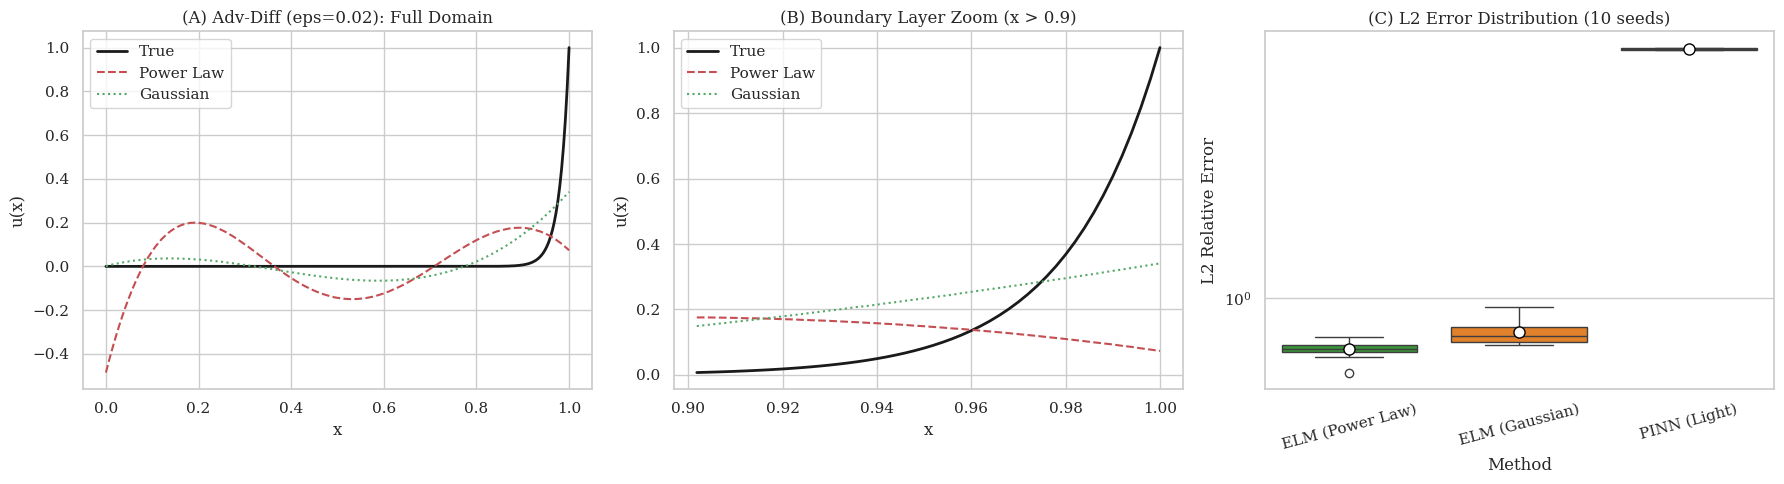

In [13]:
"""
Benchmark 7: Advection-Diffusion 1D (Boundary Layer)
-eps * u''(x) + u'(x) = 0,  x in [0, 1],  u(0) = 0, u(1) = 1
Exact: u(x) = (exp(x/eps) - 1) / (exp(1/eps) - 1)

With eps=0.02, boundary layer width ~ O(eps) = 0.02
"""
import torch
import torch.nn as nn
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def power_law_init(shape, alpha=2.0):
    u = torch.rand(shape, device=device).clamp(1e-7, 1-1e-7)
    weights = (1 - u) ** (1 / (1 - alpha))
    return (weights - weights.mean()) / (weights.std() + 1e-7) * 0.1

def gaussian_init(shape):
    return torch.randn(shape, device=device) * 0.1

def solve_elm_1d(x, u_true, h_dim, init_type='power', lambd=1e-6):
    W = power_law_init((1, h_dim)) if init_type == 'power' else gaussian_init((1, h_dim))
    b = torch.randn(h_dim, device=device) * 0.1
    start = time.time()
    H = torch.sin(x @ W + b)
    HTH = H.t() @ H + lambd * torch.eye(h_dim, device=device)
    beta = torch.linalg.solve(HTH, H.t() @ u_true)
    t_solve = time.time() - start
    u_pred = H @ beta
    err = (torch.norm(u_true - u_pred) / torch.norm(u_true)).item()
    return u_pred, err, t_solve

def solve_pinn_advdiff(x, u_true, eps, hidden=128, layers=1, iters=500, lr=0.003):
    """PINN for -eps*u'' + u' = 0 with BCs u(0)=0, u(1)=1."""
    x_grad = x.clone().detach().requires_grad_(True)
    net = [nn.Linear(1, hidden), nn.Tanh()]
    for _ in range(layers - 1):
        net += [nn.Linear(hidden, hidden), nn.Tanh()]
    net.append(nn.Linear(hidden, 1))
    model = nn.Sequential(*net).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bc_pts = torch.tensor([[0.0], [1.0]], device=device)
    bc_vals = torch.tensor([[0.0], [1.0]], device=device)

    start = time.time()
    for _ in range(iters):
        opt.zero_grad()
        u = model(x_grad)
        u_x = torch.autograd.grad(u, x_grad, torch.ones_like(u), create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_grad, torch.ones_like(u_x), create_graph=True)[0]
        # -eps*u'' + u' = 0
        residual = -eps * u_xx + u_x
        loss_pde = torch.mean(residual**2)
        loss_bc = ((model(bc_pts) - bc_vals)**2).mean()
        loss = loss_pde + 20 * loss_bc
        loss.backward()
        opt.step()
    t_solve = time.time() - start
    with torch.no_grad():
        err = (torch.norm(u_true - model(x)) / torch.norm(u_true)).item()
    return err, t_solve

# --- Setup ---
N_SEEDS = 10
h_dim = 4096
eps = 0.02  # thin boundary layer

x = torch.linspace(0, 1, 30000, device=device).view(-1, 1)

# Exact solution (numerically stable computation)
# u(x) = (exp(x/eps) - 1) / (exp(1/eps) - 1)
# For large 1/eps, exp(1/eps) dominates, so u(x) ~ exp((x-1)/eps) for x < 1
x_np = x.cpu().numpy().flatten()
u_np = np.where(
    x_np < 1 - 5*eps,
    np.exp((x_np - 1) / eps),  # asymptotic form far from boundary layer
    (np.exp(x_np / eps) - 1) / (np.exp(1 / eps) - 1)  # exact near x=1
)
u_true = torch.tensor(u_np, dtype=torch.float32, device=device).view(-1, 1)

print("="*70)
print(f"BENCHMARK 7: Advection-Diffusion 1D (eps={eps})")
print(f"u(x) = (exp(x/eps) - 1) / (exp(1/eps) - 1)")
print(f"Boundary layer width ~ O(eps) = {eps}")
print(f"u range: [{u_true.min().item():.6f}, {u_true.max().item():.6f}]")
print("="*70)

data_rows = []
for seed in range(N_SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)

    _, ep_err, ep_t = solve_elm_1d(x, u_true, h_dim, 'power')
    data_rows.append({'Method': 'ELM (Power Law)', 'L2 Error': ep_err, 'Time': ep_t})

    _, eg_err, eg_t = solve_elm_1d(x, u_true, h_dim, 'gaussian')
    data_rows.append({'Method': 'ELM (Gaussian)', 'L2 Error': eg_err, 'Time': eg_t})

    torch.manual_seed(seed)
    p_err, p_t = solve_pinn_advdiff(x, u_true, eps)
    data_rows.append({'Method': 'PINN (Light)', 'L2 Error': p_err, 'Time': p_t})

    if seed % 5 == 0:
        print(f"  Seed {seed}: PL={ep_err:.4f}, G={eg_err:.4f}, PINN={p_err:.4f}")

df_ad = pd.DataFrame(data_rows)
summary_ad = df_ad.groupby('Method').agg({'L2 Error': ['mean', 'std'], 'Time': 'mean'})
print("\n--- ADVECTION-DIFFUSION RESULTS ---")
print(summary_ad.to_markdown())

pl_err = summary_ad.loc['ELM (Power Law)', ('L2 Error', 'mean')]
g_err = summary_ad.loc['ELM (Gaussian)', ('L2 Error', 'mean')]
print(f"\nPower-Law is {g_err/pl_err:.1f}x more accurate than Gaussian")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_plot = torch.linspace(0, 1, 500, device=device).view(-1, 1)
xp_np = x_plot.cpu().numpy().flatten()
u_plot_np = np.where(
    xp_np < 1 - 5*eps,
    np.exp((xp_np - 1) / eps),
    (np.exp(xp_np / eps) - 1) / (np.exp(1 / eps) - 1)
)
u_plot_true = torch.tensor(u_plot_np, dtype=torch.float32, device=device).view(-1, 1)

torch.manual_seed(0)
u_pred_pl, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'power')
torch.manual_seed(0)
u_pred_g, _, _ = solve_elm_1d(x_plot, u_plot_true, h_dim, 'gaussian')

axes[0].plot(xp_np, u_plot_true.cpu().numpy().flatten(), 'k-', lw=2, label='True')
axes[0].plot(xp_np, u_pred_pl.cpu().detach().numpy().flatten(), 'r--', lw=1.5, label='Power Law')
axes[0].plot(xp_np, u_pred_g.cpu().detach().numpy().flatten(), 'g:', lw=1.5, label='Gaussian')
axes[0].set_title(f'(A) Adv-Diff (eps={eps}): Full Domain')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u(x)')
axes[0].legend(); axes[0].grid(True)

# Zoom into boundary layer
bl_mask = xp_np > 0.9
axes[1].plot(xp_np[bl_mask], u_plot_true.cpu().numpy().flatten()[bl_mask], 'k-', lw=2, label='True')
axes[1].plot(xp_np[bl_mask], u_pred_pl.cpu().detach().numpy().flatten()[bl_mask], 'r--', lw=1.5, label='Power Law')
axes[1].plot(xp_np[bl_mask], u_pred_g.cpu().detach().numpy().flatten()[bl_mask], 'g:', lw=1.5, label='Gaussian')
axes[1].set_title('(B) Boundary Layer Zoom (x > 0.9)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u(x)')
axes[1].legend(); axes[1].grid(True)

palette = {'ELM (Power Law)': '#2ca02c', 'ELM (Gaussian)': '#ff7f0e', 'PINN (Light)': '#1f77b4'}
sns.boxplot(x='Method', y='L2 Error', data=df_ad, hue='Method', palette=palette,
            ax=axes[2], showmeans=True, legend=False,
            meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black","markersize":"8"})
axes[2].set_yscale('log')
axes[2].set_title('(C) L2 Error Distribution (10 seeds)')
axes[2].set_ylabel('L2 Relative Error'); axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('benchmark7_advdiff.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as benchmark7_advdiff.png")
plt.show()